In [4]:
import scanpy as sc

In [5]:
data_path = '/data2/project/bin_jip/Biomarker/data/asthma/asthma_baseline_data.h5ad'
adata = sc.read_h5ad(data_path)

In [6]:
print(adata)

AnnData object with n_obs × n_vars = 259552 × 14314
    obs: 'nCount_RNA', 'nFeature_RNA', 'barcodes', 'Sample_ID', 'batch', 'PRISM_ID', 'Biologics', 'TimePoint', 'percent.mt', 'RNA_snn_res.0.3', 'RNA_snn_res.0.5', 'RNA_snn_res.0.8', 'RNA_snn_res.1.2', 'RNA_snn_res.1.5', 'RNA_snn_res.1.8', 'seurat_clusters', 'twostep_aff_0.5', 'twostep_aff_0.4', 'twostep_aff_0.3', 'twostep_aff_0.2', 'twostep_aff_0.1', 'twostepclus2', 'twostepclus3', 'twostepclus4', 'predicted.celltype.l1.score', 'predicted.celltype.l1', 'predicted.celltype.l2.score', 'predicted.celltype.l2', 'predicted.celltype.l3.score', 'predicted.celltype.l3', 'mapping.score', 'twostep_aff_0.7', 'Azimuth_UMAP1', 'Azimuth_UMAP2', 'CellType_Major', 'CellType_minor', 'Treatment', 'Response', 'Response2'
    var: 'names'
    obsm: 'X_harmony', 'X_pca', 'X_umap'
    layers: 'counts_RNA'


In [3]:
adata.obs.columns

Index(['nCount_RNA', 'nFeature_RNA', 'barcodes', 'Sample_ID', 'batch',
       'PRISM_ID', 'Biologics', 'TimePoint', 'percent.mt', 'RNA_snn_res.0.3',
       'RNA_snn_res.0.5', 'RNA_snn_res.0.8', 'RNA_snn_res.1.2',
       'RNA_snn_res.1.5', 'RNA_snn_res.1.8', 'seurat_clusters',
       'twostep_aff_0.5', 'twostep_aff_0.4', 'twostep_aff_0.3',
       'twostep_aff_0.2', 'twostep_aff_0.1', 'twostepclus2', 'twostepclus3',
       'twostepclus4', 'predicted.celltype.l1.score', 'predicted.celltype.l1',
       'predicted.celltype.l2.score', 'predicted.celltype.l2',
       'predicted.celltype.l3.score', 'predicted.celltype.l3', 'mapping.score',
       'twostep_aff_0.7', 'Azimuth_UMAP1', 'Azimuth_UMAP2', 'CellType_Major',
       'CellType_minor', 'Treatment', 'Response', 'Response2'],
      dtype='object')

<Axes: xlabel='Response2'>

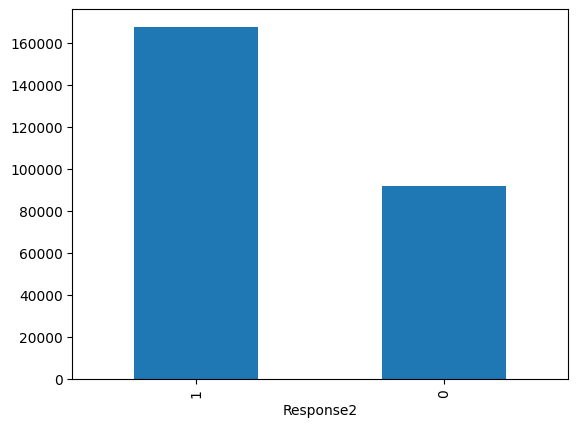

In [16]:
adata.obs['Response2'].value_counts().plot(kind='bar')

28


<Axes: xlabel='Sample_ID'>

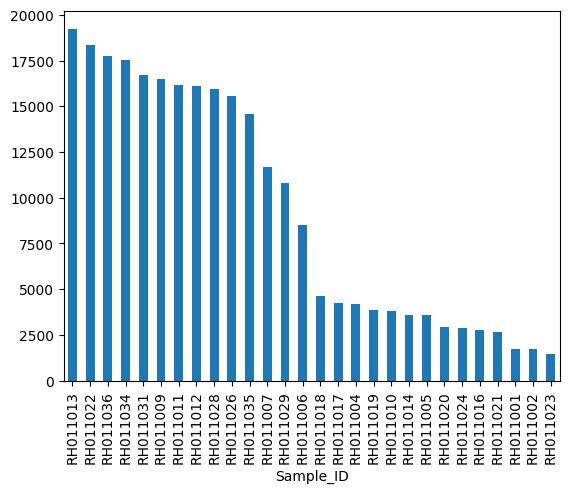

In [5]:
print(len(adata.obs['Sample_ID'].value_counts()))
adata.obs['Sample_ID'].value_counts().plot(kind='bar')

In [1]:
import multimil as mtm
import numpy as np
import scanpy as sc
import pandas as pd
import scvi
import warnings
from sklearn.model_selection import KFold

/home/bin_jip/.local/lib/python3.10/site-packages/lightning_fabric/__init__.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)
Global seed set to 0


In [2]:
sample_key = "Sample_ID"
disease_key = "Response2"

In [5]:
adata.obs[[sample_key, disease_key]].drop_duplicates().groupby(disease_key).size()

Response2
0    11
1    17
dtype: int64

In [6]:
samples = np.array(adata.obs[sample_key].unique())
len(samples)

28

In [8]:
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

for i, (train_index, val_index) in enumerate(kf.split(samples)):
    train_samples = samples[train_index]
    val_samples = samples[val_index]
    adata.obs.loc[adata.obs[sample_key].isin(train_samples), f"split{i}"] = "train"
    adata.obs.loc[adata.obs[sample_key].isin(val_samples), f"split{i}"] = "val"
    adata_train = adata[adata.obs[f"split{i}"] == "train"].copy()
    adata_val = adata[adata.obs[f"split{i}"] == "val"].copy()

    # check that all disease conditions in validation are present in training
    train_conditions = set(adata_train.obs[disease_key].unique())
    val_conditions = set(adata_val.obs[disease_key].unique())
    assert val_conditions.issubset(train_conditions)

del adata_train, adata_val

In [9]:
query = adata[adata.obs["split1"] == "val"].copy()
ref = adata[adata.obs["split1"] == "train"].copy()

query.obs["ref"] = "query"
ref.obs["ref"] = "reference"

In [10]:
query

AnnData object with n_obs × n_vars = 60551 × 14314
    obs: 'nCount_RNA', 'nFeature_RNA', 'barcodes', 'Sample_ID', 'batch', 'PRISM_ID', 'Biologics', 'TimePoint', 'percent.mt', 'RNA_snn_res.0.3', 'RNA_snn_res.0.5', 'RNA_snn_res.0.8', 'RNA_snn_res.1.2', 'RNA_snn_res.1.5', 'RNA_snn_res.1.8', 'seurat_clusters', 'twostep_aff_0.5', 'twostep_aff_0.4', 'twostep_aff_0.3', 'twostep_aff_0.2', 'twostep_aff_0.1', 'twostepclus2', 'twostepclus3', 'twostepclus4', 'predicted.celltype.l1.score', 'predicted.celltype.l1', 'predicted.celltype.l2.score', 'predicted.celltype.l2', 'predicted.celltype.l3.score', 'predicted.celltype.l3', 'mapping.score', 'twostep_aff_0.7', 'Azimuth_UMAP1', 'Azimuth_UMAP2', 'CellType_Major', 'CellType_minor', 'Treatment', 'Response', 'Response2', 'split0', 'split1', 'split2', 'split3', 'split4', 'ref'
    var: 'names'
    obsm: 'X_harmony', 'X_pca', 'X_umap'
    layers: 'counts_RNA'

In [11]:
classification_keys = [disease_key]
categorical_covariate_keys = classification_keys + [sample_key]

In [12]:
idx = ref.obs[sample_key].sort_values().index
ref = ref[idx].copy()

idx = query.obs[sample_key].sort_values().index
query = query[idx].copy()

In [13]:
mtm.model.MILClassifier.setup_anndata(
    ref,
    categorical_covariate_keys=categorical_covariate_keys,
)

/data2/project/bin_jip/miniconda3/envs/scbiomarker/lib/python3.10/abc.py:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

  return _abc_instancecheck(cls, instance)
/data2/project/bin_jip/miniconda3/envs/scbiomarker/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:90: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  warnings.warn(
/data2/project/bin_jip/miniconda3/envs/scbiomarker/lib/python3.10/site-packages/scvi/data/_utils.py:119: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  warnings.warn(


In [14]:
mil = mtm.model.MILClassifier(
    ref,
    classification=classification_keys,
    sample_key=sample_key,
    class_loss_coef=0.1,
)

Training status: Not Trained
Model's adata is minified?: False